In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

# Bank Marketing Campaign Analysis

## Business Problem

A Portuguese bank ran a series of telephone marketing campaigns to encourage clients to subscribe to **term deposits** — a savings product where a client locks money in an account for a fixed period in exchange for a guaranteed interest rate.

The core business challenge is **efficiency**: calling every client is costly, and the overall conversion rate is low (~11%). A well-performing classifier can help the bank:
- Identify clients most likely to subscribe *before* making the call
- Reduce wasted outreach on unlikely prospects
- Prioritize high-value segments in future campaigns

---

## Data Overview

| Dataset | File | Rows | Columns | Notes |
|---|---|---|---|---|
| Small (15-feature) | `bank.csv` | 4,521 | 17 | Stratified subset |
| Full (15-feature) | `bank-full.csv` | 45,211 | 17 | **Primary EDA dataset** |
| Additional (20-feature) | `bank-additional-full.csv` | 41,188 | 21 | Adds macroeconomic indicators |

The **15-feature format** (`bank-full.csv`) is used throughout this notebook. The 20-feature format will be explored in a second modeling notebook (time permitting).

In [15]:
df = pd.read_csv("../data/bank.csv", sep=";")
df.sample(n=10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2807,60,admin.,married,unknown,no,1088,yes,no,cellular,26,may,149,1,-1,0,unknown,no
2020,33,blue-collar,married,secondary,no,285,no,yes,unknown,3,jul,267,1,-1,0,unknown,no
551,34,technician,married,secondary,no,-228,yes,no,cellular,20,apr,187,3,332,3,other,no
3680,43,unemployed,divorced,secondary,no,4094,yes,no,cellular,21,nov,63,1,-1,0,unknown,no
238,57,housemaid,married,primary,no,7082,no,no,unknown,6,jun,69,3,-1,0,unknown,no
2779,52,management,married,secondary,no,-588,yes,no,cellular,22,jul,81,4,-1,0,unknown,no
3689,29,technician,married,tertiary,no,858,yes,no,cellular,12,jun,234,7,330,1,failure,no
4395,49,blue-collar,married,secondary,no,1568,no,no,unknown,21,may,206,6,-1,0,unknown,no
2451,57,admin.,married,secondary,no,3927,no,no,cellular,13,oct,61,1,-1,0,unknown,no
4405,51,technician,married,secondary,no,463,yes,no,unknown,13,may,213,5,-1,0,unknown,no


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [54]:
df_full_additional = pd.read_csv("../data/bank-additional-full.csv", sep=";")
df_full_additional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [20]:
df_full = pd.read_csv("../data/bank-full.csv", sep=";")
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [22]:
df_full.dropna()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## 2. Target Class Distribution

The target variable `y` indicates whether a client subscribed to a term deposit. The dataset is heavily **imbalanced** — understanding the baseline rate is critical before interpreting any model's accuracy.

y
no     39922
yes     5289
Name: count, dtype: int64

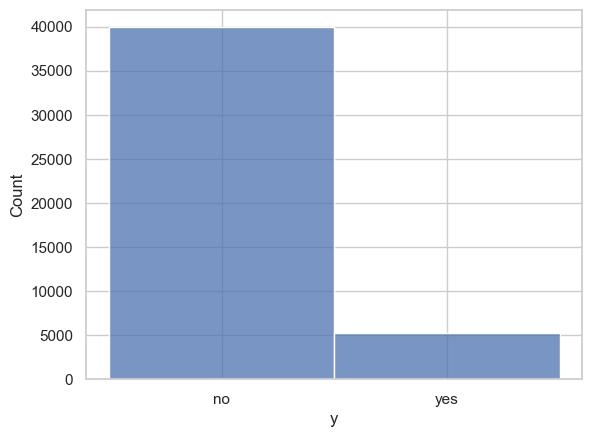

In [40]:
sns.histplot(df_full, x="y")
df_full['y'].value_counts()

**Key Finding:** ~88.5% of clients said *no*, giving a naive baseline accuracy of 88.5% — any model must meaningfully beat this to be useful. This class imbalance also means **accuracy alone is a misleading metric**; precision, recall, and F1-score will be more informative for evaluating classifier performance.

<Axes: xlabel='age', ylabel='Count'>

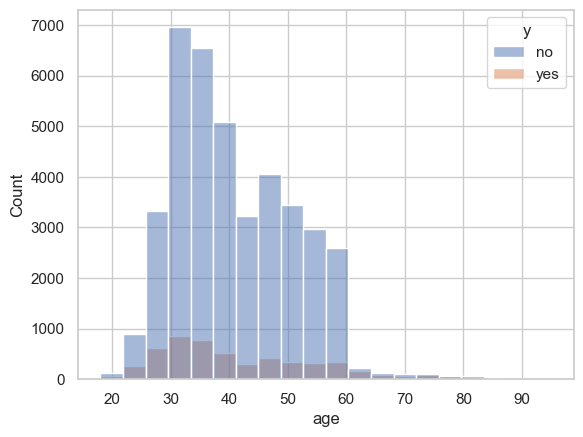

In [47]:
sns.histplot(data=df_full, x='age', hue='y', bins=20)

<Axes: xlabel='job'>

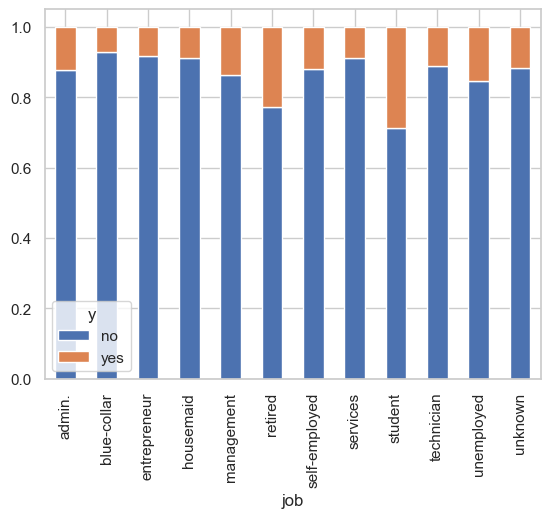

In [53]:
df_full.groupby('job')['y'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='marital'>

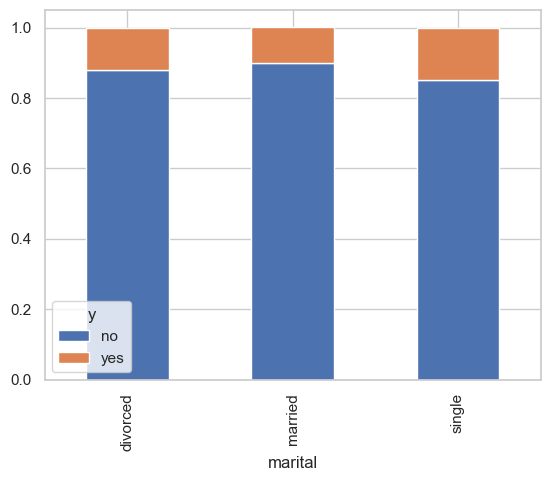

In [57]:
df_full.groupby('marital')['y'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='education'>

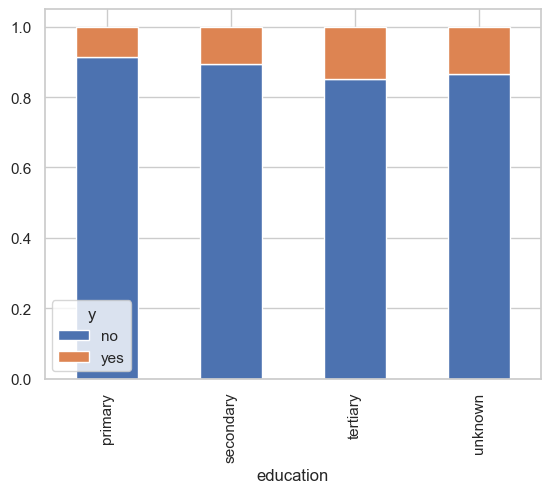

In [56]:
df_full.groupby('education')['y'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)

## 4. Campaign Contact Patterns

How the *timing* and *method* of outreach affect conversion — and whether calling a client multiple times helps or hurts.

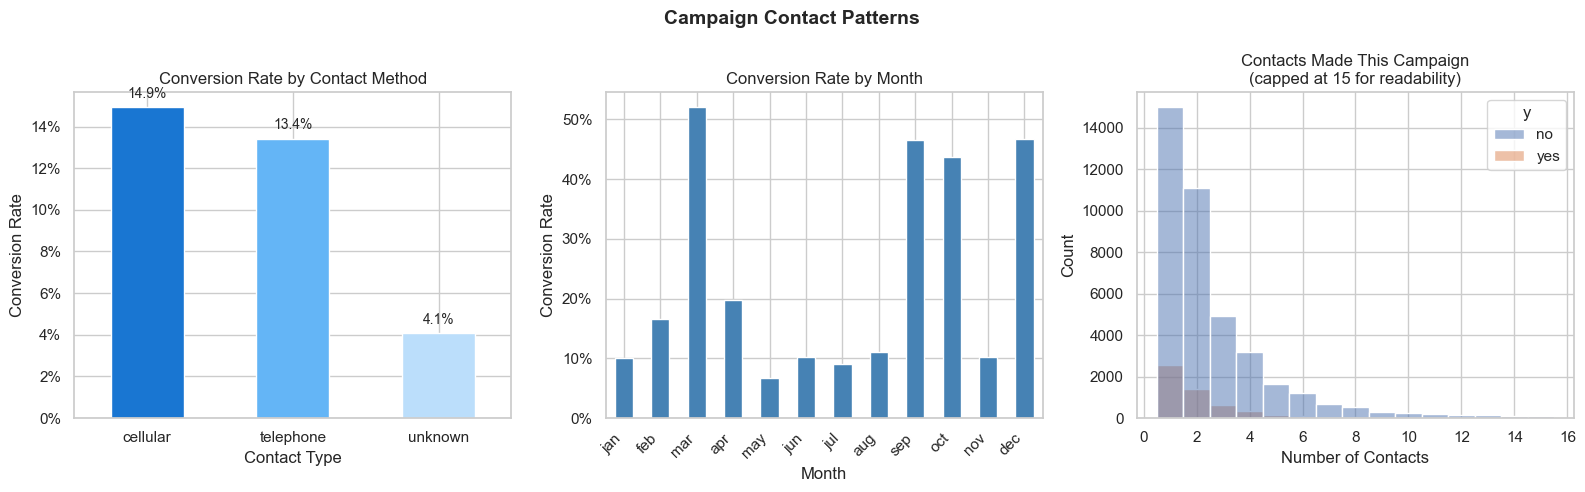

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contact method conversion rate
contact_rate = (
    df_full.groupby('contact')['y']
    .apply(lambda x: (x == 'yes').mean())
    .sort_values(ascending=False)
)
contact_rate.plot(kind='bar', ax=axes[0],
                  color=['#1976D2', '#64B5F6', '#BBDEFB'], edgecolor='white')
axes[0].set_title('Conversion Rate by Contact Method')
axes[0].set_xlabel('Contact Type')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# Month conversion rate (calendar order)
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
month_rate = (
    df_full.groupby('month')['y']
    .apply(lambda x: (x == 'yes').mean())
    .reindex(month_order)
    .dropna()
)
month_rate.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Conversion Rate by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Number of contacts made this campaign (cap at 15 for readability)
campaign_capped = df_full[df_full['campaign'] <= 15]
sns.histplot(data=campaign_capped, x='campaign', hue='y',
             bins=15, discrete=True, ax=axes[2])
axes[2].set_title('Contacts Made This Campaign\n(capped at 15 for readability)')
axes[2].set_xlabel('Number of Contacts')
axes[2].set_ylabel('Count')

plt.suptitle('Campaign Contact Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Financial Profile

Clients without a housing loan or personal loan show higher conversion rates, suggesting that existing debt obligations reduce willingness to commit to another financial product.

C:\Users\anant\AppData\Local\Temp\ipykernel_13112\3004637990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trimmed, x='y', y='balance', ax=axes[0], palette='Set2')
C:\Users\anant\AppData\Local\Temp\ipykernel_13112\3004637990.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No', 'Yes'])


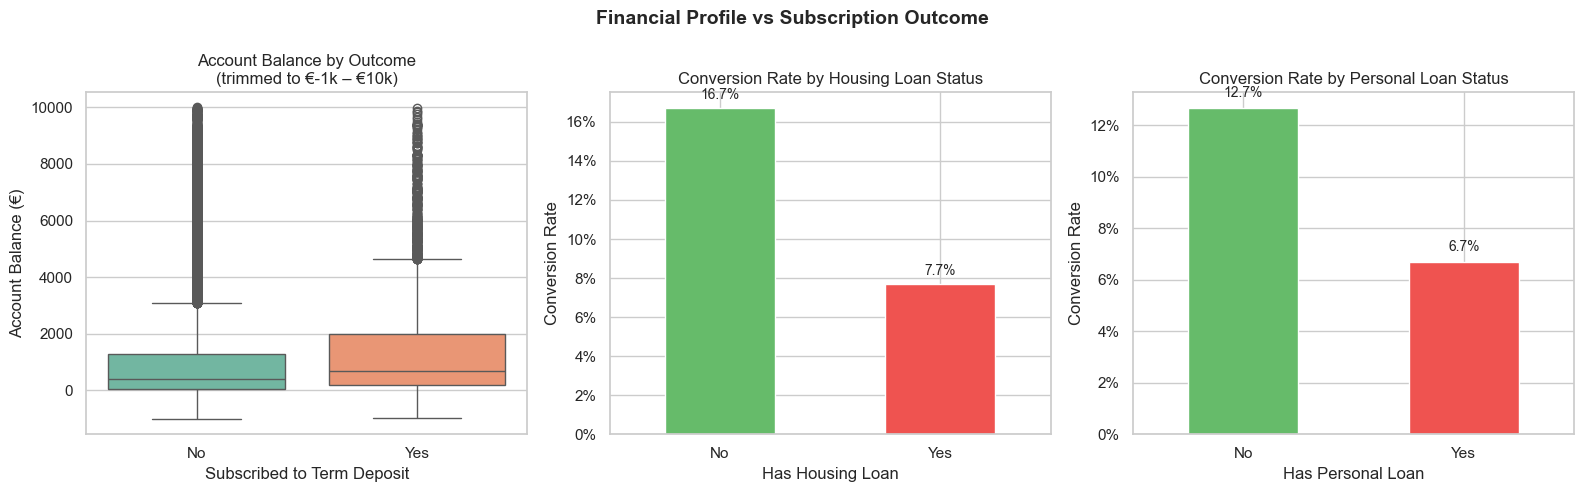

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Account balance by outcome (trim outliers for readability)
trimmed = df_full[df_full['balance'].between(-1000, 10000)]
sns.boxplot(data=trimmed, x='y', y='balance', ax=axes[0], palette='Set2')
axes[0].set_title('Account Balance by Outcome\n(trimmed to €-1k – €10k)')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Account Balance (€)')
axes[0].set_xticklabels(['No', 'Yes'])

# Housing loan conversion rate
housing_rate = df_full.groupby('housing')['y'].apply(lambda x: (x == 'yes').mean())
housing_rate.plot(kind='bar', ax=axes[1], color=['#66BB6A', '#EF5350'], edgecolor='white')
axes[1].set_title('Conversion Rate by Housing Loan Status')
axes[1].set_xlabel('Has Housing Loan')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# Personal loan conversion rate
loan_rate = df_full.groupby('loan')['y'].apply(lambda x: (x == 'yes').mean())
loan_rate.plot(kind='bar', ax=axes[2], color=['#66BB6A', '#EF5350'], edgecolor='white')
axes[2].set_title('Conversion Rate by Personal Loan Status')
axes[2].set_xlabel('Has Personal Loan')
axes[2].set_ylabel('Conversion Rate')
axes[2].set_xticklabels(['No', 'Yes'], rotation=0)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Financial Profile vs Subscription Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Previous Campaign Influence

Clients who said *yes* in a previous campaign are far more likely to convert again. `poutcome` is one of the strongest predictors in the dataset.

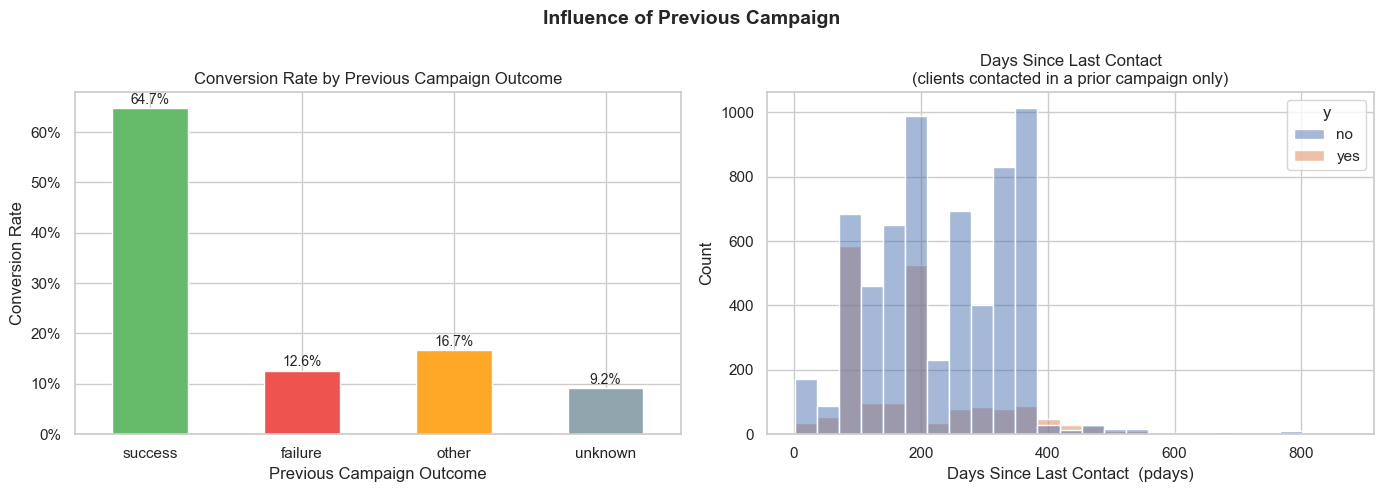

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previous campaign outcome → current subscription rate
poutcome_order = ['success', 'failure', 'other', 'unknown']
poutcome_rate = (
    df_full.groupby('poutcome')['y']
    .apply(lambda x: (x == 'yes').mean())
    .reindex(poutcome_order)
    .dropna()
)
bar_colors = ['#66BB6A', '#EF5350', '#FFA726', '#90A4AE']
poutcome_rate.plot(kind='bar', ax=axes[0], color=bar_colors[:len(poutcome_rate)], edgecolor='white')
axes[0].set_title('Conversion Rate by Previous Campaign Outcome')
axes[0].set_xlabel('Previous Campaign Outcome')
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

# Days since last contact — only clients contacted in a prior campaign (pdays != -1)
prev_contacted = df_full[df_full['pdays'] > 0]
sns.histplot(data=prev_contacted, x='pdays', hue='y', bins=25, ax=axes[1])
axes[1].set_title('Days Since Last Contact\n(clients contacted in a prior campaign only)')
axes[1].set_xlabel('Days Since Last Contact  (pdays)')
axes[1].set_ylabel('Count')

plt.suptitle('Influence of Previous Campaign', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Numeric Correlations & Feature Relationships

<Axes: >

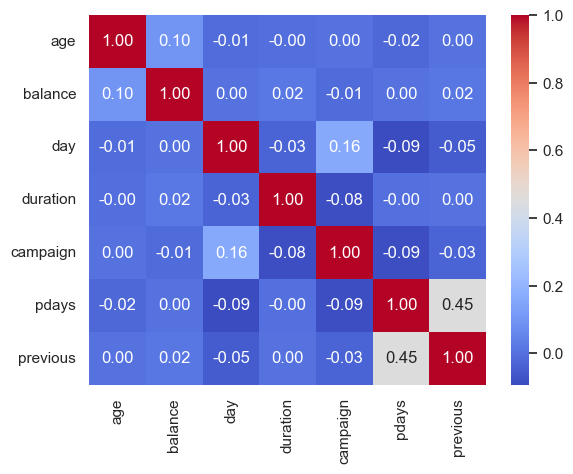

In [51]:
sns.heatmap(df_full.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm')

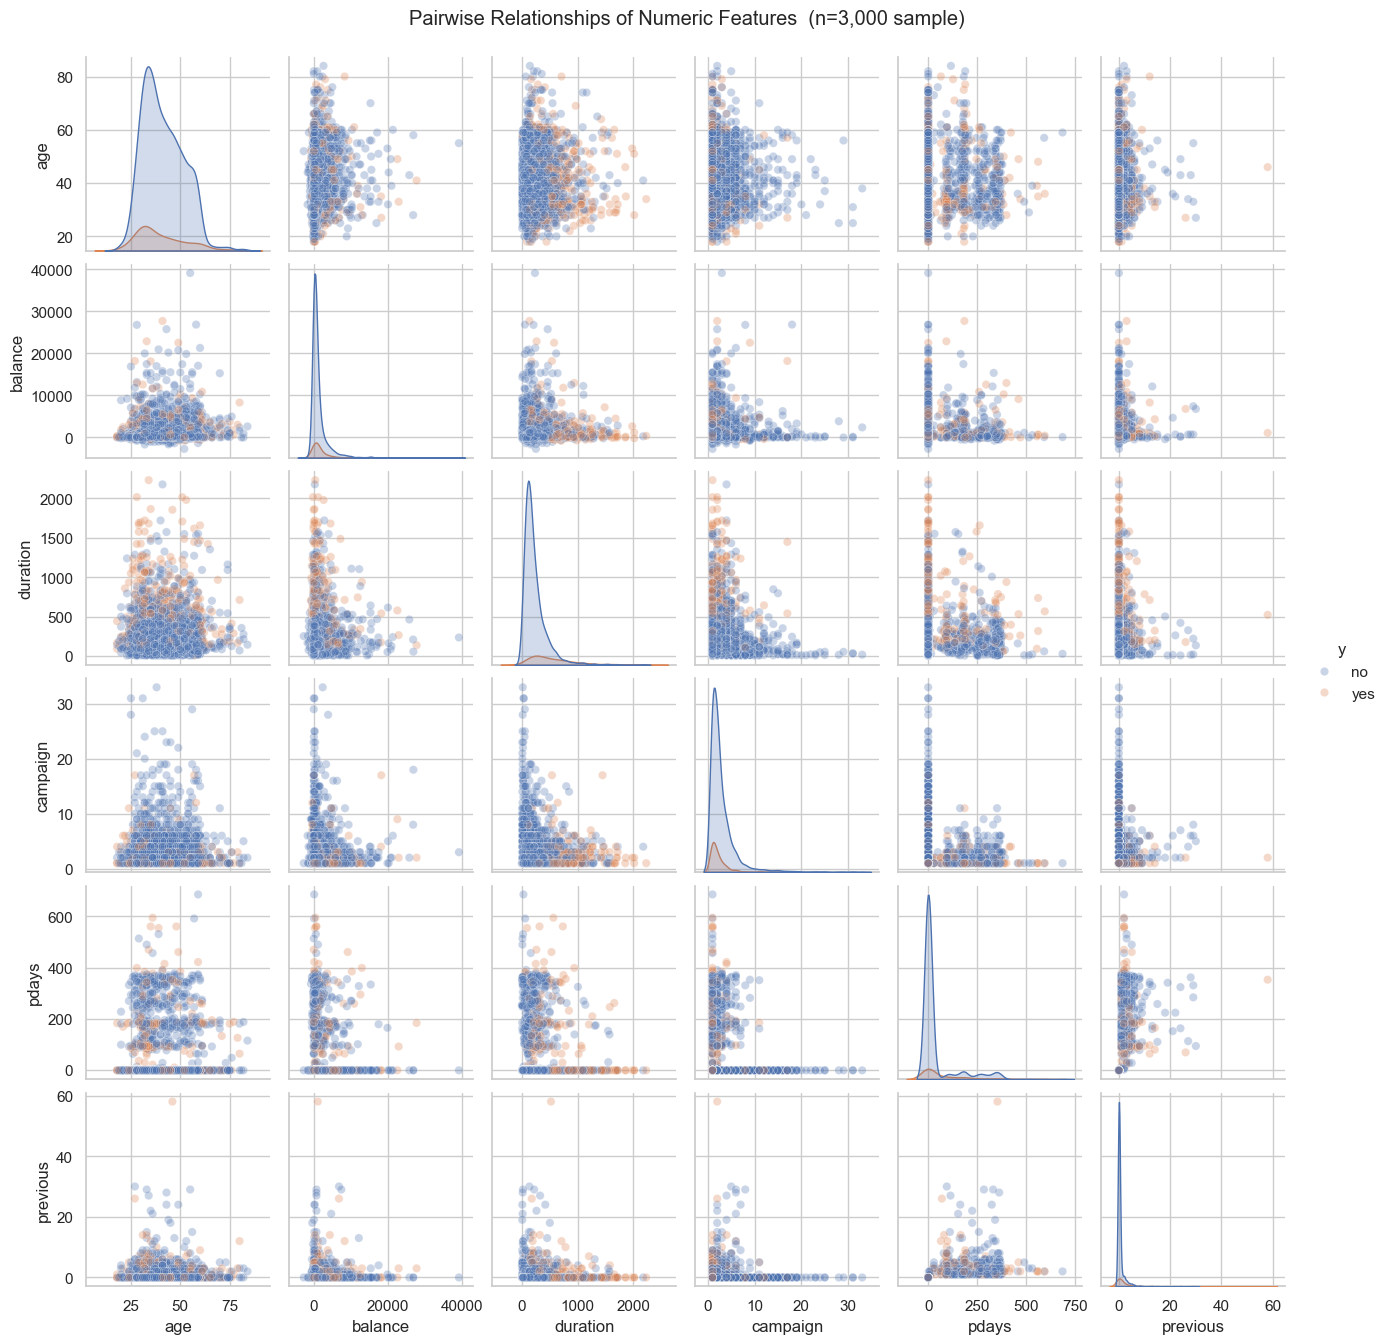

In [61]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Sample for performance — pairplot on 45k rows is slow
sample_df = df_full.sample(n=3000, random_state=42)

sns.pairplot(
    sample_df[numeric_cols + ['y']],
    hue='y',
    diag_kind='kde',
    plot_kws={'alpha': 0.3},
    height=2.2
)
plt.suptitle('Pairwise Relationships of Numeric Features  (n=3,000 sample)', y=1.02)
plt.show()

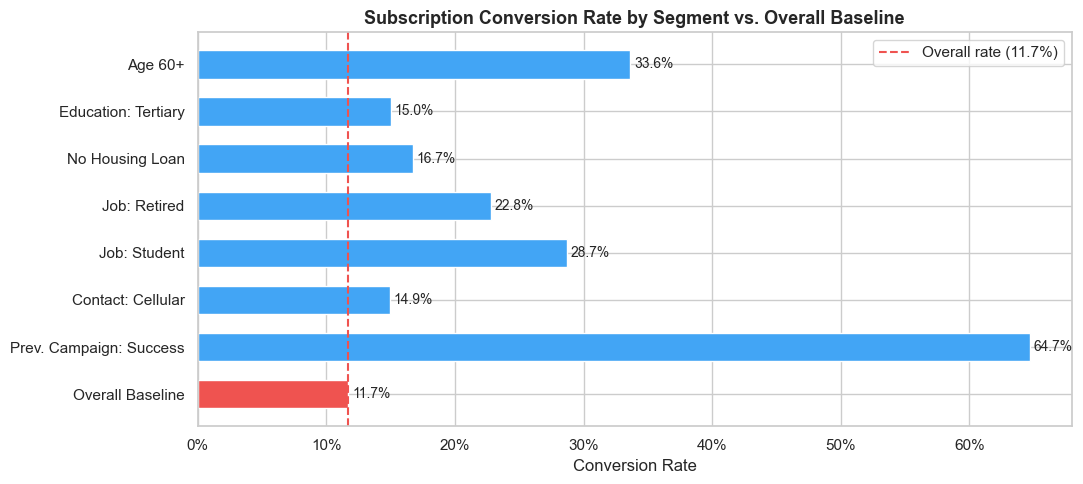

In [62]:
## 8. Segment Conversion Rate Summary

overall_rate = (df_full['y'] == 'yes').mean()

segments = {
    'Overall Baseline':          overall_rate,
    'Prev. Campaign: Success':   df_full[df_full['poutcome'] == 'success']['y'].eq('yes').mean(),
    'Contact: Cellular':         df_full[df_full['contact'] == 'cellular']['y'].eq('yes').mean(),
    'Job: Student':              df_full[df_full['job'] == 'student']['y'].eq('yes').mean(),
    'Job: Retired':              df_full[df_full['job'] == 'retired']['y'].eq('yes').mean(),
    'No Housing Loan':           df_full[df_full['housing'] == 'no']['y'].eq('yes').mean(),
    'Education: Tertiary':       df_full[df_full['education'] == 'tertiary']['y'].eq('yes').mean(),
    'Age 60+':                   df_full[df_full['age'] >= 60]['y'].eq('yes').mean(),
}

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#EF5350' if k == 'Overall Baseline' else '#42A5F5' for k in segments]
bars = ax.barh(list(segments.keys()), list(segments.values()),
               color=colors, edgecolor='white', height=0.6)
ax.axvline(overall_rate, color='#EF5350', linestyle='--', linewidth=1.5,
           label=f'Overall rate ({overall_rate:.1%})')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Subscription Conversion Rate by Segment vs. Overall Baseline',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate')
ax.legend()
for bar, val in zip(bars, segments.values()):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.show()